In [1]:
!pip -q install transformers torch matplotlib langdetect
# Optional (interactive viz):
# !pip -q install bertviz

Could not find platform independent libraries <prefix>

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Cell 2 — Imports & model choice

In [2]:
import torch, numpy as np, math
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "bert-base-multilingual-cased"

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

def tok(s):
    return tokenizer(s, return_tensors="pt").to(device)


c:\Users\DSU Student\Desktop\702\csc702_fall2025\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\DSU Student\Desktop\702\csc702_fall2025\venv\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\DSU Student\Desktop\702\csc702_fall2025\venv\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\DSU Student\Desktop\702\csc702_fall2025\venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `to

Cell 3 — Sentence pairs (EN - ES/FR/DE/NE/HI …)

In [3]:
pairs = [
    # English ↔ Spanish
    ("The cat is sleeping on the couch.", "El gato está durmiendo en el sofá."),
    # English ↔ French
    ("The animal did not cross the street because it was tired.", "L’animal n’a pas traversé la rue parce qu’il était fatigué."),
    # English ↔ German
    ("I put the book on the shelf, then I picked it up again.", "Ich stellte das Buch ins Regal, dann hob ich es wieder auf."),
    # English ↔ Hindi
    ("He is learning machine learning at the university.", "वह विश्वविद्यालय में मशीन लर्निंग सीख रहा है।"),
]


Cell 4 — Utilities: forward, hidden states, similarity & plots

In [4]:
@torch.no_grad()
def encode_hidden_states(text, output_attentions=False):
    enc = tok(text)
    out = model(**enc, output_hidden_states=True, output_attentions=output_attentions)
    # hidden_states is a tuple: layer0 (emb), layer1, ..., layerL
    # We'll return last layer token embeddings
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].cpu().tolist())
    last = out.hidden_states[-1][0]  # (seq, hidden)
    return tokens, last, (out.attentions if output_attentions else None)

def cosine_sim_mat(A, B):
    # A: (n, d), B: (m, d) -> (n, m)
    A = A / (A.norm(dim=-1, keepdim=True) + 1e-12)
    B = B / (B.norm(dim=-1, keepdim=True) + 1e-12)
    return A @ B.T

def show_heatmap(mat, xtoks, ytoks, title="Similarity", figsize=(6,6)):
    plt.figure(figsize=figsize)
    plt.imshow(mat, interpolation="nearest")
    plt.xticks(range(len(xtoks)), xtoks, rotation=90)
    plt.yticks(range(len(ytoks)), ytoks)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def strip_special(tokens):
    # Keep a readable subset (mBERT uses [CLS],[SEP]; XLM-R uses <s>,</s>,▁wordpieces)
    specials = set([tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token, tokenizer.unk_token])
    return [t for t in tokens if t is not None and t not in specials]


Cell 5 — Cross-lingual token-similarity & greedy alignment

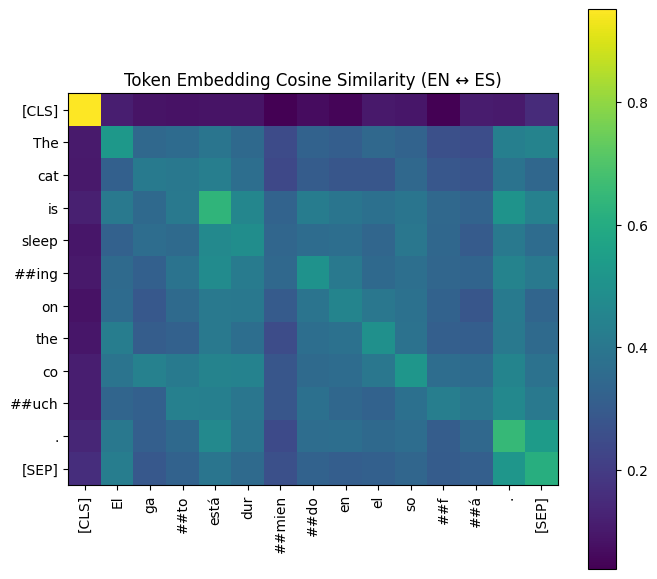

Greedy alignments (EN token ↔ ES token, cosine):
[CLS]           ↔ [CLS]            0.950
.               ↔ .                0.648
is              ↔ está             0.634
[SEP]           ↔ [SEP]            0.611
The             ↔ El               0.524
co              ↔ so               0.517
##ing           ↔ ##do             0.502
the             ↔ el               0.495
sleep           ↔ dur              0.487
on              ↔ en               0.449
##uch           ↔ ##to             0.434
cat             ↔ ga               0.415


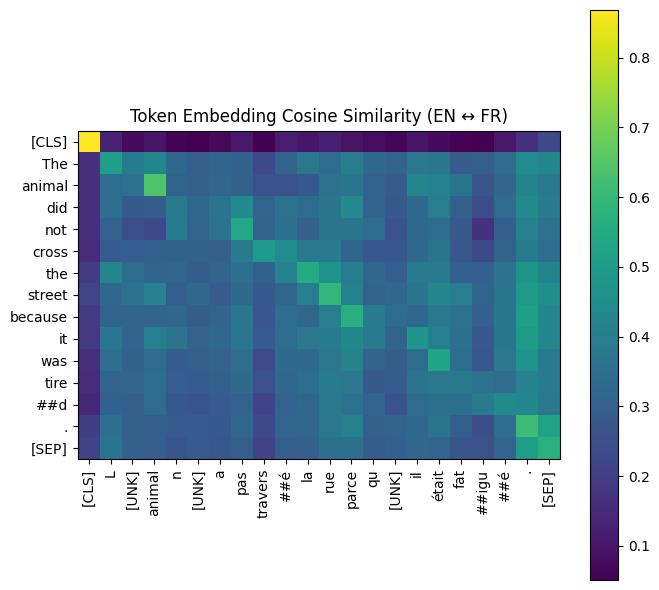

Greedy alignments (EN token ↔ FR token, cosine):
[CLS]           ↔ [CLS]            0.868
animal          ↔ animal           0.643
.               ↔ .                0.611
street          ↔ rue              0.588
[SEP]           ↔ [SEP]            0.574
because         ↔ parce            0.563
the             ↔ la               0.554
not             ↔ pas              0.543
was             ↔ était            0.529
The             ↔ L                0.509
cross           ↔ travers          0.489
it              ↔ il               0.479
##d             ↔ ##é              0.439
did             ↔ n                0.386
tire            ↔ fat              0.382


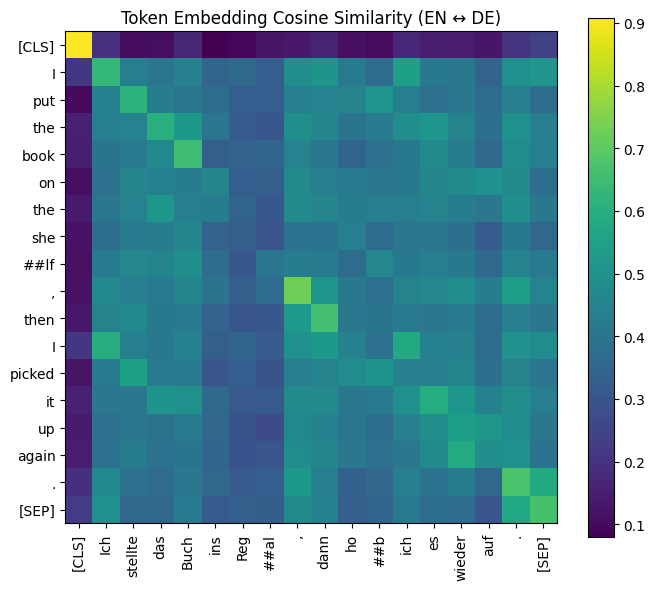

Greedy alignments (EN token ↔ DE token, cosine):
[CLS]           ↔ [CLS]            0.908
,               ↔ ,                0.724
.               ↔ .                0.675
[SEP]           ↔ [SEP]            0.669
then            ↔ dann             0.660
book            ↔ Buch             0.651
I               ↔ Ich              0.633
put             ↔ stellte          0.615
the             ↔ das              0.606
it              ↔ es               0.594
again           ↔ wieder           0.588
I               ↔ ich              0.584
up              ↔ auf              0.519
picked          ↔ ##b              0.509
on              ↔ ins              0.457


In [5]:
def greedy_alignment(sim, src_toks, tgt_toks, topk=10, min_len=1):
    # simple 1-1 greedy: pick best pairs without reuse
    sim_np = sim.cpu().numpy()
    used_src, used_tgt = set(), set()
    pairs = []
    # Flatten indices by score
    flat = []
    for i in range(sim_np.shape[0]):
        for j in range(sim_np.shape[1]):
            flat.append((sim_np[i,j], i, j))
    flat.sort(reverse=True)
    for score, i, j in flat:
        if i in used_src or j in used_tgt:
            continue
        # skip tiny subword tokens if you want stricter alignment (optional filters)
        if len(src_toks[i]) < min_len or len(tgt_toks[j]) < min_len:
            continue
        used_src.add(i); used_tgt.add(j)
        pairs.append((i, j, float(score)))
        if len(pairs) >= topk:
            break
    return pairs

def crosslingual_compare(en, xx, title_lang=""):
    # Encode
    en_toks, en_last, _ = encode_hidden_states(en)
    xx_toks, xx_last, _ = encode_hidden_states(xx)

    # Optionally drop specials for display but keep indices consistent
    # Instead, we visualize with specials kept so matrices align to tokens
    sim = cosine_sim_mat(en_last, xx_last)  # (en_seq, xx_seq)

    # Plot similarity matrix
    show_heatmap(sim.cpu().numpy(), xx_toks, en_toks,
                 title=f"Token Embedding Cosine Similarity (EN ↔ {title_lang})",
                 figsize=(7,6))

    # Print greedy alignment pairs
    pairs = greedy_alignment(sim, en_toks, xx_toks, topk=15, min_len=1)
    print(f"Greedy alignments (EN token ↔ {title_lang} token, cosine):")
    for i, j, s in pairs:
        print(f"{en_toks[i]:<15} ↔ {xx_toks[j]:<15}  {s:.3f}")

# Try first 3 pairs
crosslingual_compare(pairs[0][0], pairs[0][1], title_lang="ES")
crosslingual_compare(pairs[1][0], pairs[1][1], title_lang="FR")
crosslingual_compare(pairs[2][0], pairs[2][1], title_lang="DE")


Cell 6 — Translation vs Paraphrase test (are patterns stable?)


=== Pair 1 ===


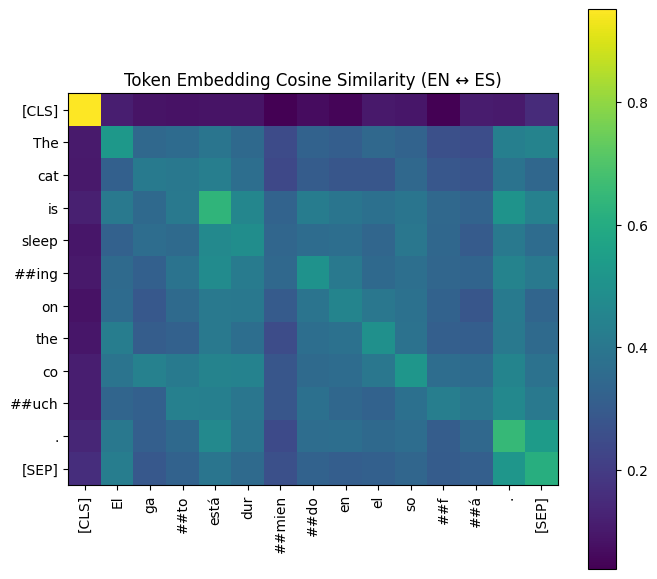

Greedy alignments (EN token ↔ ES token, cosine):
[CLS]           ↔ [CLS]            0.950
.               ↔ .                0.648
is              ↔ está             0.634
[SEP]           ↔ [SEP]            0.611
The             ↔ El               0.524
co              ↔ so               0.517
##ing           ↔ ##do             0.502
the             ↔ el               0.495
sleep           ↔ dur              0.487
on              ↔ en               0.449
##uch           ↔ ##to             0.434
cat             ↔ ga               0.415

=== Pair 2 ===


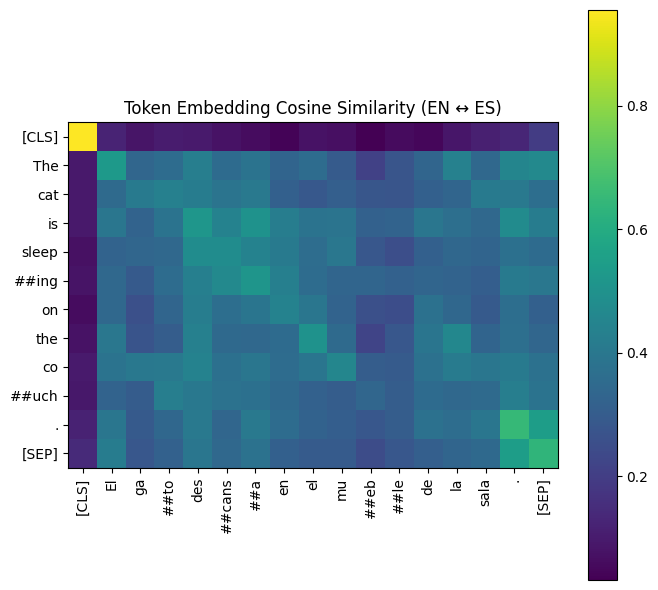

Greedy alignments (EN token ↔ ES token, cosine):
[CLS]           ↔ [CLS]            0.955
.               ↔ .                0.648
[SEP]           ↔ [SEP]            0.635
The             ↔ El               0.531
is              ↔ des              0.517
##ing           ↔ ##a              0.512
the             ↔ el               0.501
sleep           ↔ ##cans           0.479
co              ↔ mu               0.457
on              ↔ en               0.440
cat             ↔ ##to             0.435
##uch           ↔ de               0.354


In [6]:
tests = [
    # True translation
    ("The cat is sleeping on the couch.", "El gato está durmiendo en el sofá."),
    # NOT exact translation (paraphrase / partial mismatch)
    ("The cat is sleeping on the couch.", "El gato descansa en el mueble de la sala."),  # paraphrase
]

for i, (en, es) in enumerate(tests, 1):
    print(f"\n=== Pair {i} ===")
    crosslingual_compare(en, es, title_lang="ES")


Cell 7 — Layer probing (which layer aligns best?)

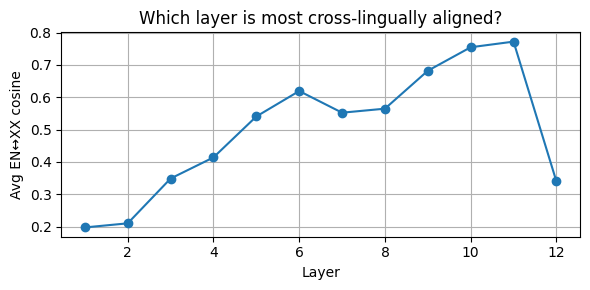

In [7]:
@torch.no_grad()
def layerwise_similarity(en, xx):
    enc_en = tok(en)
    enc_xx = tok(xx)
    out_en = model(**enc_en, output_hidden_states=True)
    out_xx = model(**enc_xx, output_hidden_states=True)
    en_toks = tokenizer.convert_ids_to_tokens(enc_en["input_ids"][0].cpu().tolist())
    xx_toks = tokenizer.convert_ids_to_tokens(enc_xx["input_ids"][0].cpu().tolist())
    sims = []
    for L in range(1, len(out_en.hidden_states)):  # skip embedding layer 0
        HE = out_en.hidden_states[L][0]  # (seq, dim)
        HX = out_xx.hidden_states[L][0]
        sims.append(cosine_sim_mat(HE, HX).mean().item())
    return sims, en_toks, xx_toks

en, xx = pairs[0]
curve, _, _ = layerwise_similarity(en, xx)
plt.figure(figsize=(6,3))
plt.plot(range(1, len(curve)+1), curve, marker="o")
plt.xlabel("Layer")
plt.ylabel("Avg EN↔XX cosine")
plt.title("Which layer is most cross-lingually aligned?")
plt.grid(True); plt.tight_layout(); plt.show()


This function shows how a Transformer pays attention to relationships between words in English vs. its translation, layer-by-layer and head-by-head.

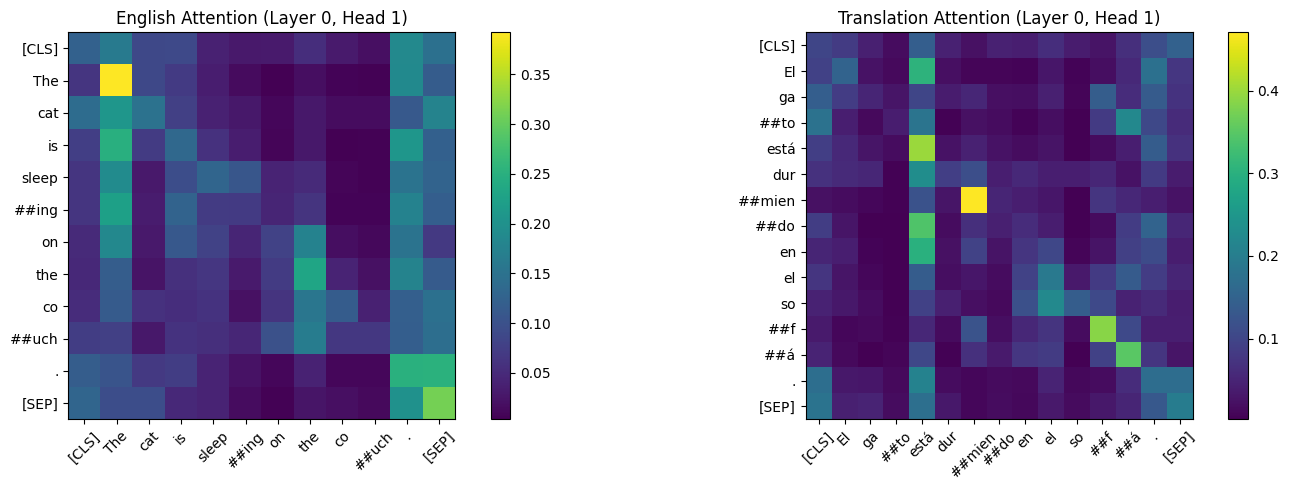

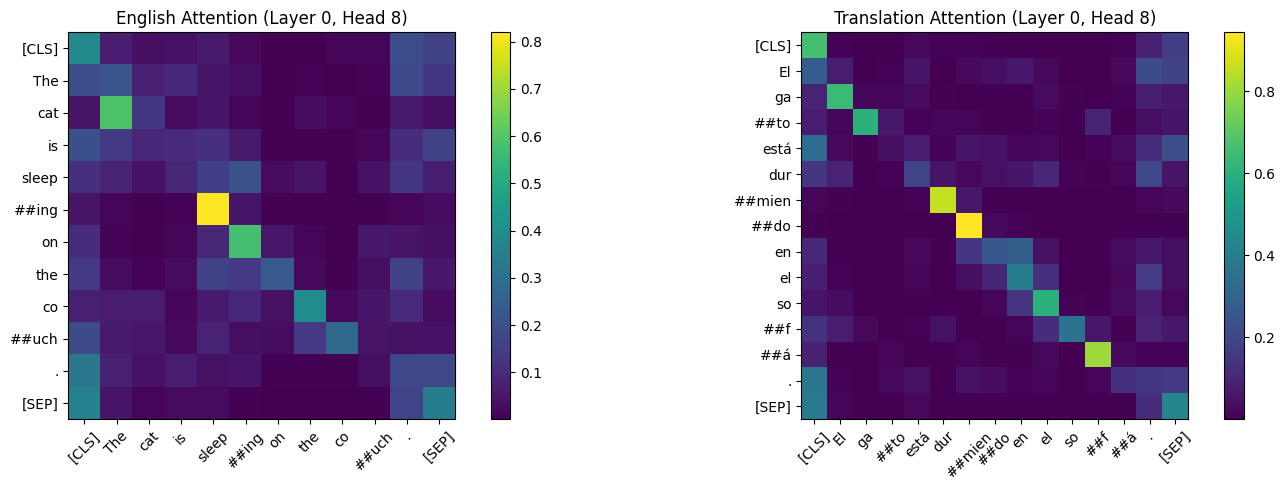

In [8]:
def plot_attention_patterns(en, xx, layer=-1, head=0):
    # Encode both sentences and get attention
    en_toks, _, en_att = encode_hidden_states(en, output_attentions=True)
    xx_toks, _, xx_att = encode_hidden_states(xx, output_attentions=True)
    
    # Get attention patterns for specified layer and head
    en_attention = en_att[layer][0][head].cpu()  # shape: (seq_len, seq_len)
    xx_attention = xx_att[layer][0][head].cpu()
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot English attention
    im1 = ax1.imshow(en_attention)
    ax1.set_xticks(range(len(en_toks)))
    ax1.set_yticks(range(len(en_toks)))
    ax1.set_xticklabels(en_toks, rotation=45)
    ax1.set_yticklabels(en_toks)
    ax1.set_title(f"English Attention (Layer {layer+1}, Head {head+1})")
    
    # Plot other language attention
    im2 = ax2.imshow(xx_attention)
    ax2.set_xticks(range(len(xx_toks)))
    ax2.set_yticks(range(len(xx_toks)))
    ax2.set_xticklabels(xx_toks, rotation=45)
    ax2.set_yticklabels(xx_toks)
    ax2.set_title(f"Translation Attention (Layer {layer+1}, Head {head+1})")
    
    # Add colorbar
    fig.colorbar(im1, ax=ax1)
    fig.colorbar(im2, ax=ax2)
    
    plt.tight_layout()
    plt.show()

# Test with first pair of sentences
en, es = pairs[0]
plot_attention_patterns(en, es, layer=-1, head=0)  # Last layer, first head
plot_attention_patterns(en, es, layer=-1, head=7)  # Last layer, last head

Cell 9 — Language Detection and Metrics

In [9]:
from collections import Counter
import langdetect

def detect_language(text):
    try:
        return langdetect.detect(text)
    except:
        return "unknown"

def calculate_alignment_metrics(en, xx):
    # Encode both sentences
    en_toks, en_last, _ = encode_hidden_states(en)
    xx_toks, xx_last, _ = encode_hidden_states(xx)
    
    # Calculate similarity matrix
    sim = cosine_sim_mat(en_last, xx_last)
    
    # Get alignments
    pairs = greedy_alignment(sim, en_toks, xx_toks, topk=len(en_toks))
    
    # Calculate metrics
    avg_similarity = sum(s for _, _, s in pairs) / len(pairs)
    max_similarity = max(s for _, _, s in pairs)
    min_similarity = min(s for _, _, s in pairs)
    
    # Detect languages
    src_lang = detect_language(en)
    tgt_lang = detect_language(xx)
    
    return {
        "source_language": src_lang,
        "target_language": tgt_lang,
        "avg_similarity": avg_similarity,
        "max_similarity": max_similarity,
        "min_similarity": min_similarity,
        "num_alignments": len(pairs)
    }

# Test the metrics on all pairs
for i, (en, xx) in enumerate(pairs):
    print(f"\n=== Pair {i+1} ===")
    metrics = calculate_alignment_metrics(en, xx)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.3f}")
        else:
            print(f"{k}: {v}")


=== Pair 1 ===
source_language: en
target_language: es
avg_similarity: 0.556
max_similarity: 0.950
min_similarity: 0.415
num_alignments: 12

=== Pair 2 ===
source_language: en
target_language: fr
avg_similarity: 0.544
max_similarity: 0.868
min_similarity: 0.382
num_alignments: 15

=== Pair 3 ===
source_language: en
target_language: de
avg_similarity: 0.588
max_similarity: 0.908
min_similarity: 0.346
num_alignments: 18

=== Pair 4 ===
source_language: en
target_language: hi
avg_similarity: 0.497
max_similarity: 0.919
min_similarity: 0.375
num_alignments: 11
